
<div align="center">

# **Diseño de volante de inercia**

**Bogotá, 01 de marzo de 2026**

**Nombre:** Sergio Emanuel Ropero
**Código:** 20216



## 1. Uso de IA y referencias

•	Se utilizó una herramienta de IA generativa como apoyo para ordenar la estructura del informe, redactar a partir de la información técnica suministrada, revisar claridad y consistencia del documento, y asistir en tareas de programación y depuración del código bajo un esquema de apoyo tipo pair coding. Las decisiones de modelado, los supuestos ingenieriles, la selección de parámetros, la validación numérica y la revisión final se realizaron sin ayuda de la IA.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path
from IPython.display import display, Image

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

In [2]:
# defs and helper functions
ROOT = Path.cwd().resolve()
if not (ROOT / 'datasets').exists():
    ROOT = ROOT.parent
OUTPUT_DIR = ROOT / 'datasets' / 'volante_inercia_6061'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Geometry [m]
OA = 80e-3
AB = 240e-3
BC = 200e-3
C = np.array([-190e-3, -70e-3], dtype=float)

# Bars
rho_bar = 2700.0  # Al 6061-T6 [kg/m^3]
bar_w = 25e-3
bar_t = 10e-3
bar_area = bar_w * bar_t
omega_in = 30.0  # rad/s

def solve_configuration(theta, B_prev=None):
    A = np.array([OA * np.cos(theta), OA * np.sin(theta)], dtype=float)
    d = C - A
    D = np.linalg.norm(d)
    ex = d / D
    x = (AB**2 - BC**2 + D**2) / (2 * D)
    y = np.sqrt(max(AB**2 - x**2, 0.0))
    base = A + x * ex
    perp = np.array([-ex[1], ex[0]], dtype=float)
    B1 = base + y * perp
    B2 = base - y * perp

    if B_prev is None:
        B = B1 if B1[1] > B2[1] else B2
    else:
        B = B1 if np.linalg.norm(B1 - B_prev) < np.linalg.norm(B2 - B_prev) else B2

    theta_ab = np.arctan2(B[1] - A[1], B[0] - A[0])
    theta_bc = np.arctan2(B[1] - C[1], B[0] - C[0])
    return A, B, theta_ab, theta_bc


def periodic_grad(y, x):
    h = x[1] - x[0]
    return (np.roll(y, -1) - np.roll(y, 1)) / (2 * h)


def cumulative_trapezoid_periodic(y, x):
    inc = 0.5 * (y[1:] + y[:-1]) * np.diff(x)
    return np.concatenate(([0.0], np.cumsum(inc)))


def interp_periodic(xgrid, ygrid, x):
    return np.interp(np.mod(x, 2 * np.pi), xgrid, ygrid)


def mechanism_cycle(n=2001):
    theta = np.linspace(0.0, 2 * np.pi, n)

    A_pts = []
    B_pts = []
    th_ab = []
    th_bc = []
    B_prev = None

    for th in theta:
        A, B, a_ab, a_bc = solve_configuration(th, B_prev)
        B_prev = B
        A_pts.append(A)
        B_pts.append(B)
        th_ab.append(a_ab)
        th_bc.append(a_bc)

    A_pts = np.asarray(A_pts)
    B_pts = np.asarray(B_pts)
    th_ab = np.unwrap(np.asarray(th_ab))
    th_bc = np.unwrap(np.asarray(th_bc))

    om_ab_unit = []
    om_bc_unit = []
    al_ab_unit = []
    al_bc_unit = []

    for th, a_ab, a_bc in zip(theta, th_ab, th_bc):
        M = np.array([
            [-AB * np.sin(a_ab),  BC * np.sin(a_bc)],
            [ AB * np.cos(a_ab), -BC * np.cos(a_bc)],
        ], dtype=float)

        b_vel = np.array([OA * np.sin(th), -OA * np.cos(th)], dtype=float)
        wab, wbc = np.linalg.solve(M, b_vel)
        om_ab_unit.append(wab)
        om_bc_unit.append(wbc)

        b_acc = np.array([
            OA * np.cos(th) + AB * wab**2 * np.cos(a_ab) - BC * wbc**2 * np.cos(a_bc),
            OA * np.sin(th) + AB * wab**2 * np.sin(a_ab) - BC * wbc**2 * np.sin(a_bc),
        ], dtype=float)
        aab, abc = np.linalg.solve(M, b_acc)
        al_ab_unit.append(aab)
        al_bc_unit.append(abc)

    om_ab = omega_in * np.asarray(om_ab_unit)
    om_bc = omega_in * np.asarray(om_bc_unit)
    al_ab = omega_in**2 * np.asarray(al_ab_unit)
    al_bc = omega_in**2 * np.asarray(al_bc_unit)

    lengths = np.array([OA, AB, BC], dtype=float)
    masses = rho_bar * bar_area * lengths
    inertias = masses * lengths**2 / 12.0

    G_oa = A_pts / 2.0
    G_ab = 0.5 * (A_pts + B_pts)
    G_bc = 0.5 * (B_pts + C)

    vA = np.column_stack((-OA * omega_in * np.sin(theta), OA * omega_in * np.cos(theta)))
    vG_oa = np.column_stack((-omega_in * G_oa[:, 1], omega_in * G_oa[:, 0]))

    rG_A = G_ab - A_pts
    vG_ab = vA + np.column_stack((-om_ab * rG_A[:, 1], om_ab * rG_A[:, 0]))

    rG_C = G_bc - C
    vG_bc = np.column_stack((-om_bc * rG_C[:, 1], om_bc * rG_C[:, 0]))

    T = (
        0.5 * masses[0] * np.sum(vG_oa**2, axis=1) + 0.5 * inertias[0] * omega_in**2 +
        0.5 * masses[1] * np.sum(vG_ab**2, axis=1) + 0.5 * inertias[1] * om_ab**2 +
        0.5 * masses[2] * np.sum(vG_bc**2, axis=1) + 0.5 * inertias[2] * om_bc**2
    )

    V = 9.81 * (masses[0] * G_oa[:, 1] + masses[1] * G_ab[:, 1] + masses[2] * G_bc[:, 1])

    J_eq = 2 * T / omega_in**2
    tau_inertia = 0.5 * periodic_grad(J_eq, theta) * omega_in**2
    tau_gravity = periodic_grad(V, theta)
    tau_total = tau_inertia + tau_gravity

    E_acc = cumulative_trapezoid_periodic(tau_total, theta)
    DeltaE = E_acc.max() - E_acc.min()

    return {
        'theta': theta,
        'A_pts': A_pts,
        'B_pts': B_pts,
        'th_ab': th_ab,
        'th_bc': th_bc,
        'om_ab': om_ab,
        'om_bc': om_bc,
        'al_ab': al_ab,
        'al_bc': al_bc,
        'T': T,
        'V': V,
        'J_eq': J_eq,
        'tau_inertia': tau_inertia,
        'tau_gravity': tau_gravity,
        'tau_total': tau_total,
        'E_acc': E_acc,
        'DeltaE': DeltaE,
        'masses': masses,
        'inertias': inertias,
    }


def direct_dynamics(theta_grid, J_eq, V, I_flywheel=0.0, theta0=0.0, omega0=30.0, tau_motor=0.0):
    dJ = periodic_grad(J_eq, theta_grid)
    dV = periodic_grad(V, theta_grid)

    def ode(t, y):
        th, om = y
        Jtot = interp_periodic(theta_grid, J_eq, th) + I_flywheel
        tau_gen = 0.5 * interp_periodic(theta_grid, dJ, th) * om**2 + interp_periodic(theta_grid, dV, th)
        alpha = (tau_motor - tau_gen) / Jtot
        return np.array([om, alpha], dtype=float)

    def one_turn(t, y):
        return y[0] - (theta0 + 2 * np.pi)

    one_turn.terminal = True
    one_turn.direction = 1

    sol = solve_ivp(
        ode,
        (0.0, 2.0),
        np.array([theta0, omega0], dtype=float),
        events=one_turn,
        max_step=1e-4,
        rtol=1e-8,
        atol=1e-10,
    )

    om = sol.y[1]
    om_mean = float(np.mean(om))
    Cs_real = float((om.max() - om.min()) / om_mean)

    return {
        'time': sol.t,
        'theta': sol.y[0],
        'omega': om,
        'omega_min': float(om.min()),
        'omega_max': float(om.max()),
        'omega_mean': om_mean,
        'Cs_real': Cs_real,
    }


def plot_mechanism_samples(res):
    theta = res['theta']
    A_pts = res['A_pts']
    B_pts = res['B_pts']
    idx = np.linspace(0, len(theta) - 1, 6, dtype=int)
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(idx)))

    fig, ax = plt.subplots(figsize=(7, 6))
    for color, i in zip(colors, idx):
        A = A_pts[i]
        B = B_pts[i]
        ax.plot([0.0, A[0]], [0.0, A[1]], color=color, lw=3)
        ax.plot([A[0], B[0]], [A[1], B[1]], color=color, lw=2.4)
        ax.plot([C[0], B[0]], [C[1], B[1]], color=color, lw=2.4)
        ax.scatter([0.0, A[0], B[0], C[0]], [0.0, A[1], B[1], C[1]], color=color, s=28)

    ax.plot([C[0], 0.0], [C[1], 0.0], 'k--', lw=2, label='Bastidor')
    ax.text(0.005, -0.015, 'O', fontsize=11)
    ax.text(C[0] - 0.012, C[1] - 0.015, 'C', fontsize=11)
    ax.set_title('Configuraciones del mecanismo durante una vuelta del cigüeñal')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.axis('equal')
    ax.legend()
    fig.tight_layout()
    return fig


def plot_kinematics(res):
    theta_deg = np.degrees(res['theta'])
    fig, ax = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    ax[0].plot(theta_deg, np.degrees(res['th_ab']), label='theta_AB', lw=2.2)
    ax[0].plot(theta_deg, np.degrees(res['th_bc']), label='theta_BC', lw=2.2)
    ax[0].set_ylabel('Ángulo [deg]')
    ax[0].legend()

    ax[1].plot(theta_deg, res['om_ab'], label='omega_AB', lw=2.2)
    ax[1].plot(theta_deg, res['om_bc'], label='omega_BC', lw=2.2)
    ax[1].set_ylabel('Velocidad [rad/s]')
    ax[1].legend()

    ax[2].plot(theta_deg, res['al_ab'], label='alpha_AB', lw=2.2)
    ax[2].plot(theta_deg, res['al_bc'], label='alpha_BC', lw=2.2)
    ax[2].set_ylabel('Aceleración [rad/s^2]')
    ax[2].set_xlabel('Ángulo del cigüeñal OA [deg]')
    ax[2].legend()

    fig.suptitle('Respuesta cinemática de los eslabones móviles', y=0.995)
    fig.tight_layout()
    return fig


def plot_torque(res):
    theta_deg = np.degrees(res['theta'])
    fig, ax = plt.subplots(figsize=(8, 5.6))
    ax.plot(theta_deg, res['tau_total'], label='Torque total requerido', lw=2.6, color='#003049')
    ax.plot(theta_deg, res['tau_inertia'], label='Componente inercial', lw=1.8, color='#d62828')
    ax.plot(theta_deg, res['tau_gravity'], label='Componente gravitacional', lw=1.8, color='#f77f00')
    ax.axhline(0.0, color='black', lw=1.0, ls='--')
    ax.set_title('Torque de entrada necesario para imponer omega_OA = 30 rad/s')
    ax.set_xlabel('Ángulo del cigüeñal OA [deg]')
    ax.set_ylabel('Torque [N m]')
    ax.legend()
    fig.tight_layout()
    return fig


def plot_energy(res, I_flywheel, Cs_target):
    theta_deg = np.degrees(res['theta'])
    fig, ax = plt.subplots(2, 1, figsize=(8, 8.5), sharex=True)

    ax[0].plot(theta_deg, res['E_acc'], lw=2.4, color='#264653')
    ax[0].axhline(res['E_acc'].max(), color='#2a9d8f', ls='--', lw=1.3)
    ax[0].axhline(res['E_acc'].min(), color='#e76f51', ls='--', lw=1.3)
    ax[0].set_ylabel('Energía acumulada [J]')
    ax[0].set_title('Método energético para el volante adoptado')

    ax[1].plot(theta_deg, 0 * theta_deg + I_flywheel, color='#d62828', lw=2.0)
    ax[1].fill_between(theta_deg, 0 * theta_deg, 0 * theta_deg + I_flywheel, color='#d62828', alpha=0.15)
    ax[1].set_ylabel('Inercia adoptada [kg m^2]')
    ax[1].set_xlabel('Ángulo del cigüeñal OA [deg]')
    ax[1].set_title(f'Volante adoptado para Cs = {100*Cs_target:.0f}%')

    fig.tight_layout()
    return fig


def plot_verification(sim_no, sim_yes):
    theta_no = np.degrees(sim_no['theta'] - sim_no['theta'][0])
    theta_yes = np.degrees(sim_yes['theta'] - sim_yes['theta'][0])
    fig, ax = plt.subplots(figsize=(8, 5.6))
    ax.plot(theta_no, sim_no['omega'], label='Sin volante', lw=2.1, color='#d62828')
    ax.plot(theta_yes, sim_yes['omega'], label='Con volante seleccionado', lw=2.4, color='#1d3557')
    ax.axhline(30.0, color='black', ls='--', lw=1.0, label='Velocidad nominal')
    ax.set_title('Verificación por dinámica directa con torque de motor constante')
    ax.set_xlabel('Avance angular del cigüeñal durante una vuelta [deg]')
    ax.set_ylabel('Velocidad angular OA [rad/s]')
    ax.legend()
    fig.tight_layout()
    return fig

## 2. Datos de entrada y supuestos

In [3]:
res = mechanism_cycle()

geom_df = pd.DataFrame({
    'Parámetro': ['OA', 'AB', 'BC', 'CO horizontal', 'CO vertical', '|CO|', 'Velocidad impuesta', 'Material barras', 'Sección base'],
    'Valor': [
        f'{OA*1000:.0f} mm',
        f'{AB*1000:.0f} mm',
        f'{BC*1000:.0f} mm',
        f'{abs(C[0])*1000:.0f} mm',
        f'{abs(C[1])*1000:.0f} mm',
        f'{np.linalg.norm(C)*1000:.2f} mm',
        f'{omega_in:.1f} rad/s',
        'Al 6061-T6',
        '25 mm x 10 mm',
    ]
})

display(geom_df)
print('Ley de escalamiento: k = A_real / 250 mm^2')

,Parámetro,Valor
0,OA,80 mm
1,AB,240 mm
2,BC,200 mm
3,CO horizontal,190 mm
4,CO vertical,70 mm
5,|CO|,202.48 mm
6,Velocidad impuesta,30.0 rad/s
7,Material barras,Al 6061-T6
8,Sección base,25 mm x 10 mm


Ley de escalamiento: k = A_real / 250 mm^2


## 3. Cinemática y dinámica del mecanismo

In [4]:
theta = res['theta']
A_pts = res['A_pts']
B_pts = res['B_pts']
th_ab = res['th_ab']
th_bc = res['th_bc']
om_ab = res['om_ab']
om_bc = res['om_bc']
al_ab = res['al_ab']
al_bc = res['al_bc']
tau_total = res['tau_total']
J_eq = res['J_eq']
DeltaE = res['DeltaE']
masses = res['masses']
inertias = res['inertias']

bars_df = pd.DataFrame({
    'Eslabón': ['OA', 'AB', 'BC'],
    'Longitud [m]': [OA, AB, BC],
    'Masa [kg]': masses,
    'Inercia centroidal [kg m^2]': inertias,
})

summary_df = pd.DataFrame({
    'Métrica': [
        'Torque máximo', 'Torque mínimo', 'Torque RMS', 'Torque promedio',
        'Máxima inercia equivalente', 'Inercia equivalente media',
        'max |omega_AB|', 'max |omega_BC|', 'max |alpha_AB|', 'max |alpha_BC|', 'Delta E'
    ],
    'Valor': [
        f'{tau_total.max():.3f} N m',
        f'{tau_total.min():.3f} N m',
        f'{np.sqrt(np.mean(tau_total**2)):.3f} N m',
        f'{np.trapz(tau_total, theta)/(2*np.pi):.5f} N m',
        f'{J_eq.max():.6f} kg m^2',
        f'{J_eq.mean():.6f} kg m^2',
        f'{np.max(np.abs(om_ab)):.2f} rad/s',
        f'{np.max(np.abs(om_bc)):.2f} rad/s',
        f'{np.max(np.abs(al_ab)):.1f} rad/s^2',
        f'{np.max(np.abs(al_bc)):.1f} rad/s^2',
        f'{DeltaE:.3f} J',
    ],
})

display(bars_df)
display(summary_df)

/var/folders/zl/hrt8lnh14rs7lmm5_d_43zvw0000gn/T/ipykernel_28448/4111054891.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  f'{np.trapz(tau_total, theta)/(2*np.pi):.5f} N m',


,Eslabón,Longitud [m],Masa [kg],Inercia centroidal [kg m^2]
0,OA,0.08,0.054,0.000029
1,AB,0.24,0.162,0.000778
2,BC,0.20,0.135,0.000450


,Métrica,Valor
0,Torque máximo,2.172 N m
1,Torque mínimo,-1.341 N m
2,Torque RMS,0.749 N m
3,Torque promedio,-0.00009 N m
4,Máxima inercia equivalente,0.002950 kg m^2
5,Inercia equivalente media,0.001199 kg m^2
6,max |omega_AB|,19.61 rad/s
7,max |omega_BC|,22.41 rad/s
8,max |alpha_AB|,797.8 rad/s^2
9,max |alpha_BC|,1010.2 rad/s^2


## 4. Volante adoptado

In [5]:
Cs_target = 0.03
I_flywheel = 0.04245736134595101
Ro = 150.0
Ri = 110.0
thickness = 9.568724003091072
mass_flywheel = 2.4541827367601745
sigma_flywheel = 0.1589625

flywheel_df = pd.DataFrame({
    'Parámetro': ['Material', 'Cs objetivo', 'If', 'Ro', 'Ri', 'Espesor', 'Masa', 'sigma aprox'],
    'Valor': [
        'Acero AISI 1045',
        '3%',
        f'{I_flywheel:.5f} kg m^2',
        f'{Ro:.0f} mm',
        f'{Ri:.0f} mm',
        f'{thickness:.2f} mm',
        f'{mass_flywheel:.3f} kg',
        f'{sigma_flywheel:.4f} MPa',
    ],
})

display(flywheel_df)
print(f'Comprobación rápida: If = DeltaE / (Cs * omega^2) = {DeltaE / (Cs_target * omega_in**2):.5f} kg m^2')

,Parámetro,Valor
0,Material,Acero AISI 1045
1,Cs objetivo,3%
2,If,0.04246 kg m^2
3,Ro,150 mm
4,Ri,110 mm
5,Espesor,9.57 mm
6,Masa,2.454 kg
7,sigma aprox,0.1590 MPa


Comprobación rápida: If = DeltaE / (Cs * omega^2) = 0.04246 kg m^2


## 5. Verificación por dinámica directa

In [6]:
tau_mean = float(np.trapz(res['tau_total'], res['theta']) / (2*np.pi))

sim_no = direct_dynamics(res['theta'], res['J_eq'], res['V'], I_flywheel=0.0, omega0=omega_in, tau_motor=tau_mean)
sim_yes = direct_dynamics(res['theta'], res['J_eq'], res['V'], I_flywheel=I_flywheel, omega0=omega_in, tau_motor=tau_mean)

verification_df = pd.DataFrame({
    'Caso': ['Sin volante', 'Con volante adoptado'],
    'omega min [rad/s]': [sim_no['omega_min'], sim_yes['omega_min']],
    'omega max [rad/s]': [sim_no['omega_max'], sim_yes['omega_max']],
    'omega media [rad/s]': [sim_no['omega_mean'], sim_yes['omega_mean']],
    'Cs real [%]': [100 * sim_no['Cs_real'], 100 * sim_yes['Cs_real']],
})

display(verification_df)

/var/folders/zl/hrt8lnh14rs7lmm5_d_43zvw0000gn/T/ipykernel_28448/2247741189.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tau_mean = float(np.trapz(res['tau_total'], res['theta']) / (2*np.pi))


,Caso,omega min [rad/s],omega max [rad/s],omega media [rad/s],Cs real [%]
0,Sin volante,15.389442,40.379082,23.132570,108.027943
1,Con volante adoptado,29.273359,30.130462,29.825515,2.873724


## 6. Motor adoptado

In [7]:
J_total_max = float(res['J_eq'].max()) + I_flywheel
alpha_start = 15.0
startup_torque = J_total_max * alpha_start + float(res['tau_total'].max())
startup_torque_sf = 1.5 * startup_torque

motor_df = pd.DataFrame({
    'Criterio': [
        'Jtotal,max',
        'Torque de arranque estimado',
        'Torque de diseño con FS = 1.5',
        'Modelo adoptado',
        'Tipo',
        'Torque nominal',
        'Torque máximo',
        'Inercia permisible',
    ],
    'Valor': [
        f'{J_total_max:.5f} kg m^2',
        f'{startup_torque:.3f} N m',
        f'{startup_torque_sf:.3f} N m',
        'Oriental Motor NXM920A-PS10',
        'Servo tuning-free de 200 W con reductor planetario 10:1',
        '5.73 N m',
        '17.2 N m',
        '0.081 kg m^2',
    ],
})

display(motor_df)
print('Ficha oficial: https://catalog.orientalmotor.com/item/l-categories-servo-motors-tuning-free-servo-motors/200w-nx-series-servo-motors/nxm920a-ps10')

,Criterio,Valor
0,"Jtotal,max",0.04541 kg m^2
1,Torque de arranque estimado,2.853 N m
2,Torque de diseño con FS = 1.5,4.279 N m
3,Modelo adoptado,Oriental Motor NXM920A-PS10
4,Tipo,Servo tuning-free de 200 W con reductor planet...
5,Torque nominal,5.73 N m
6,Torque máximo,17.2 N m
7,Inercia permisible,0.081 kg m^2


Ficha oficial: https://catalog.orientalmotor.com/item/l-categories-servo-motors-tuning-free-servo-motors/200w-nx-series-servo-motors/nxm920a-ps10


## 7. Figuras

<project-root>/datasets/volante_inercia_6061/01_mecanismo.png


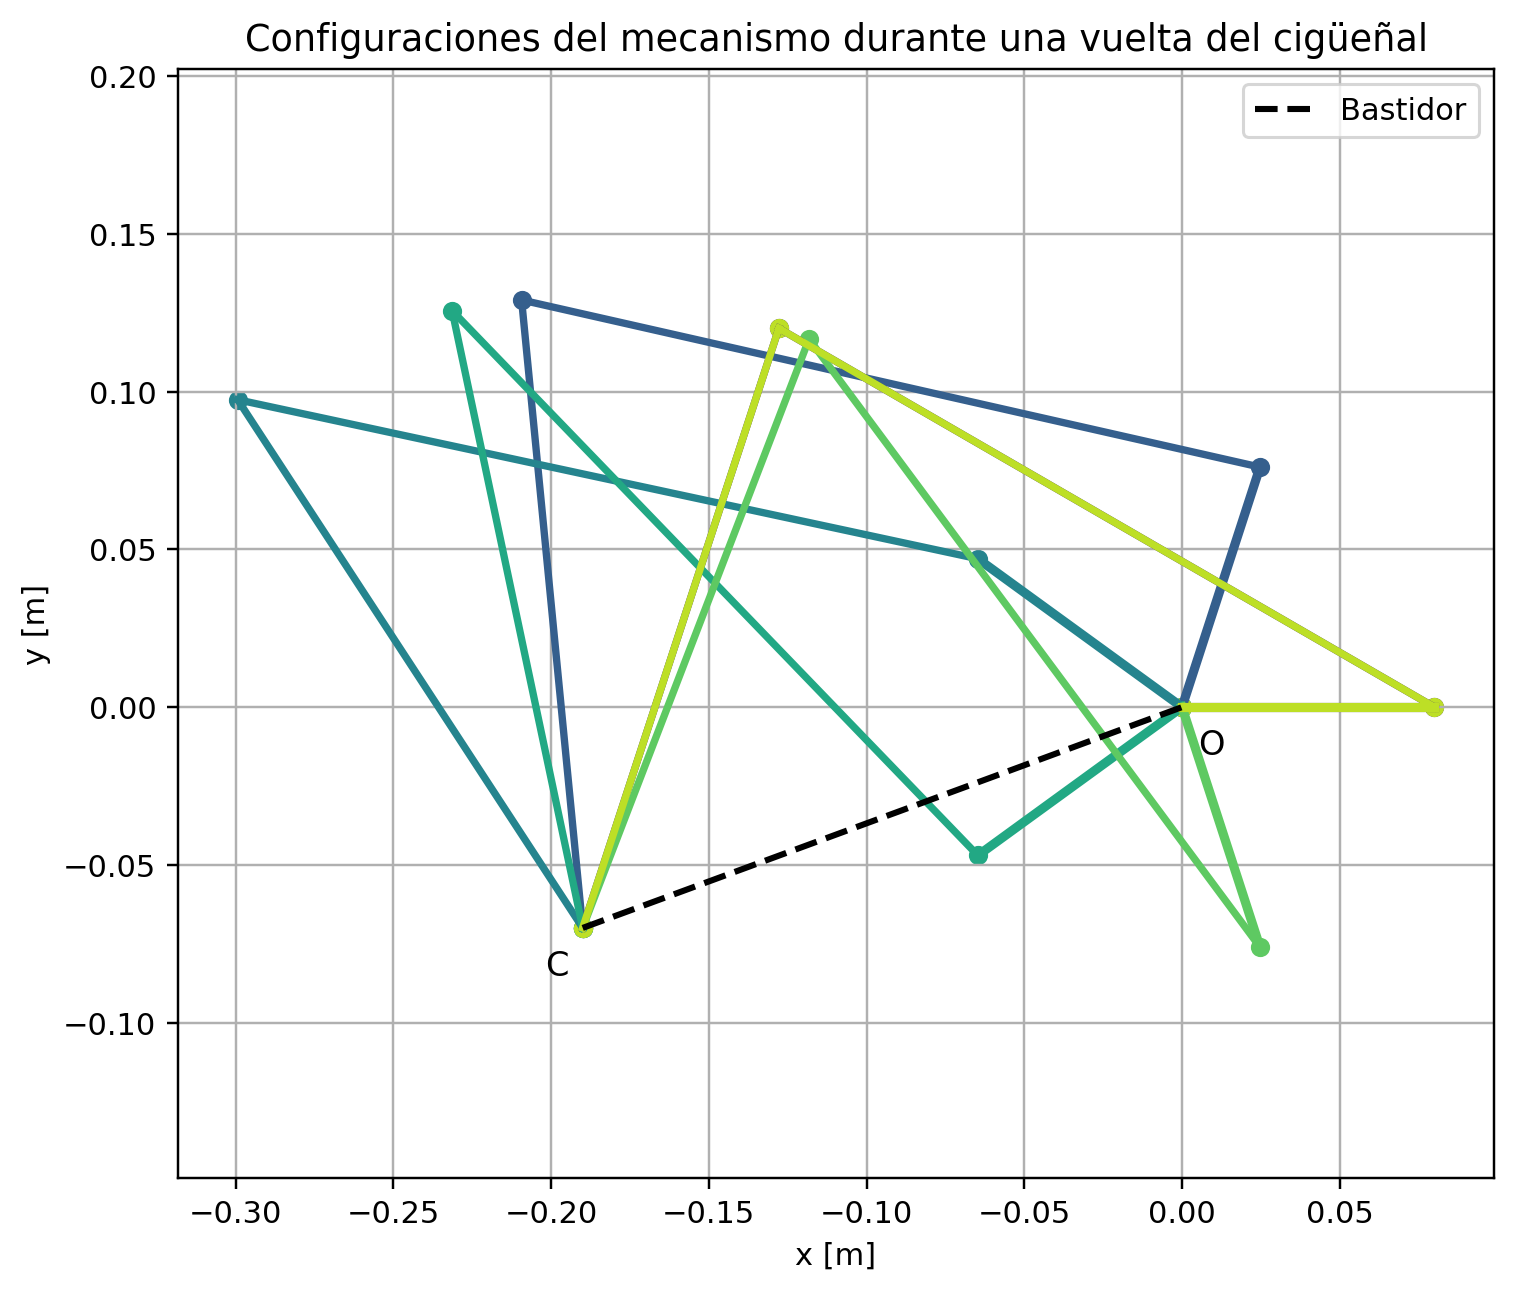

<project-root>/datasets/volante_inercia_6061/02_cinematica.png


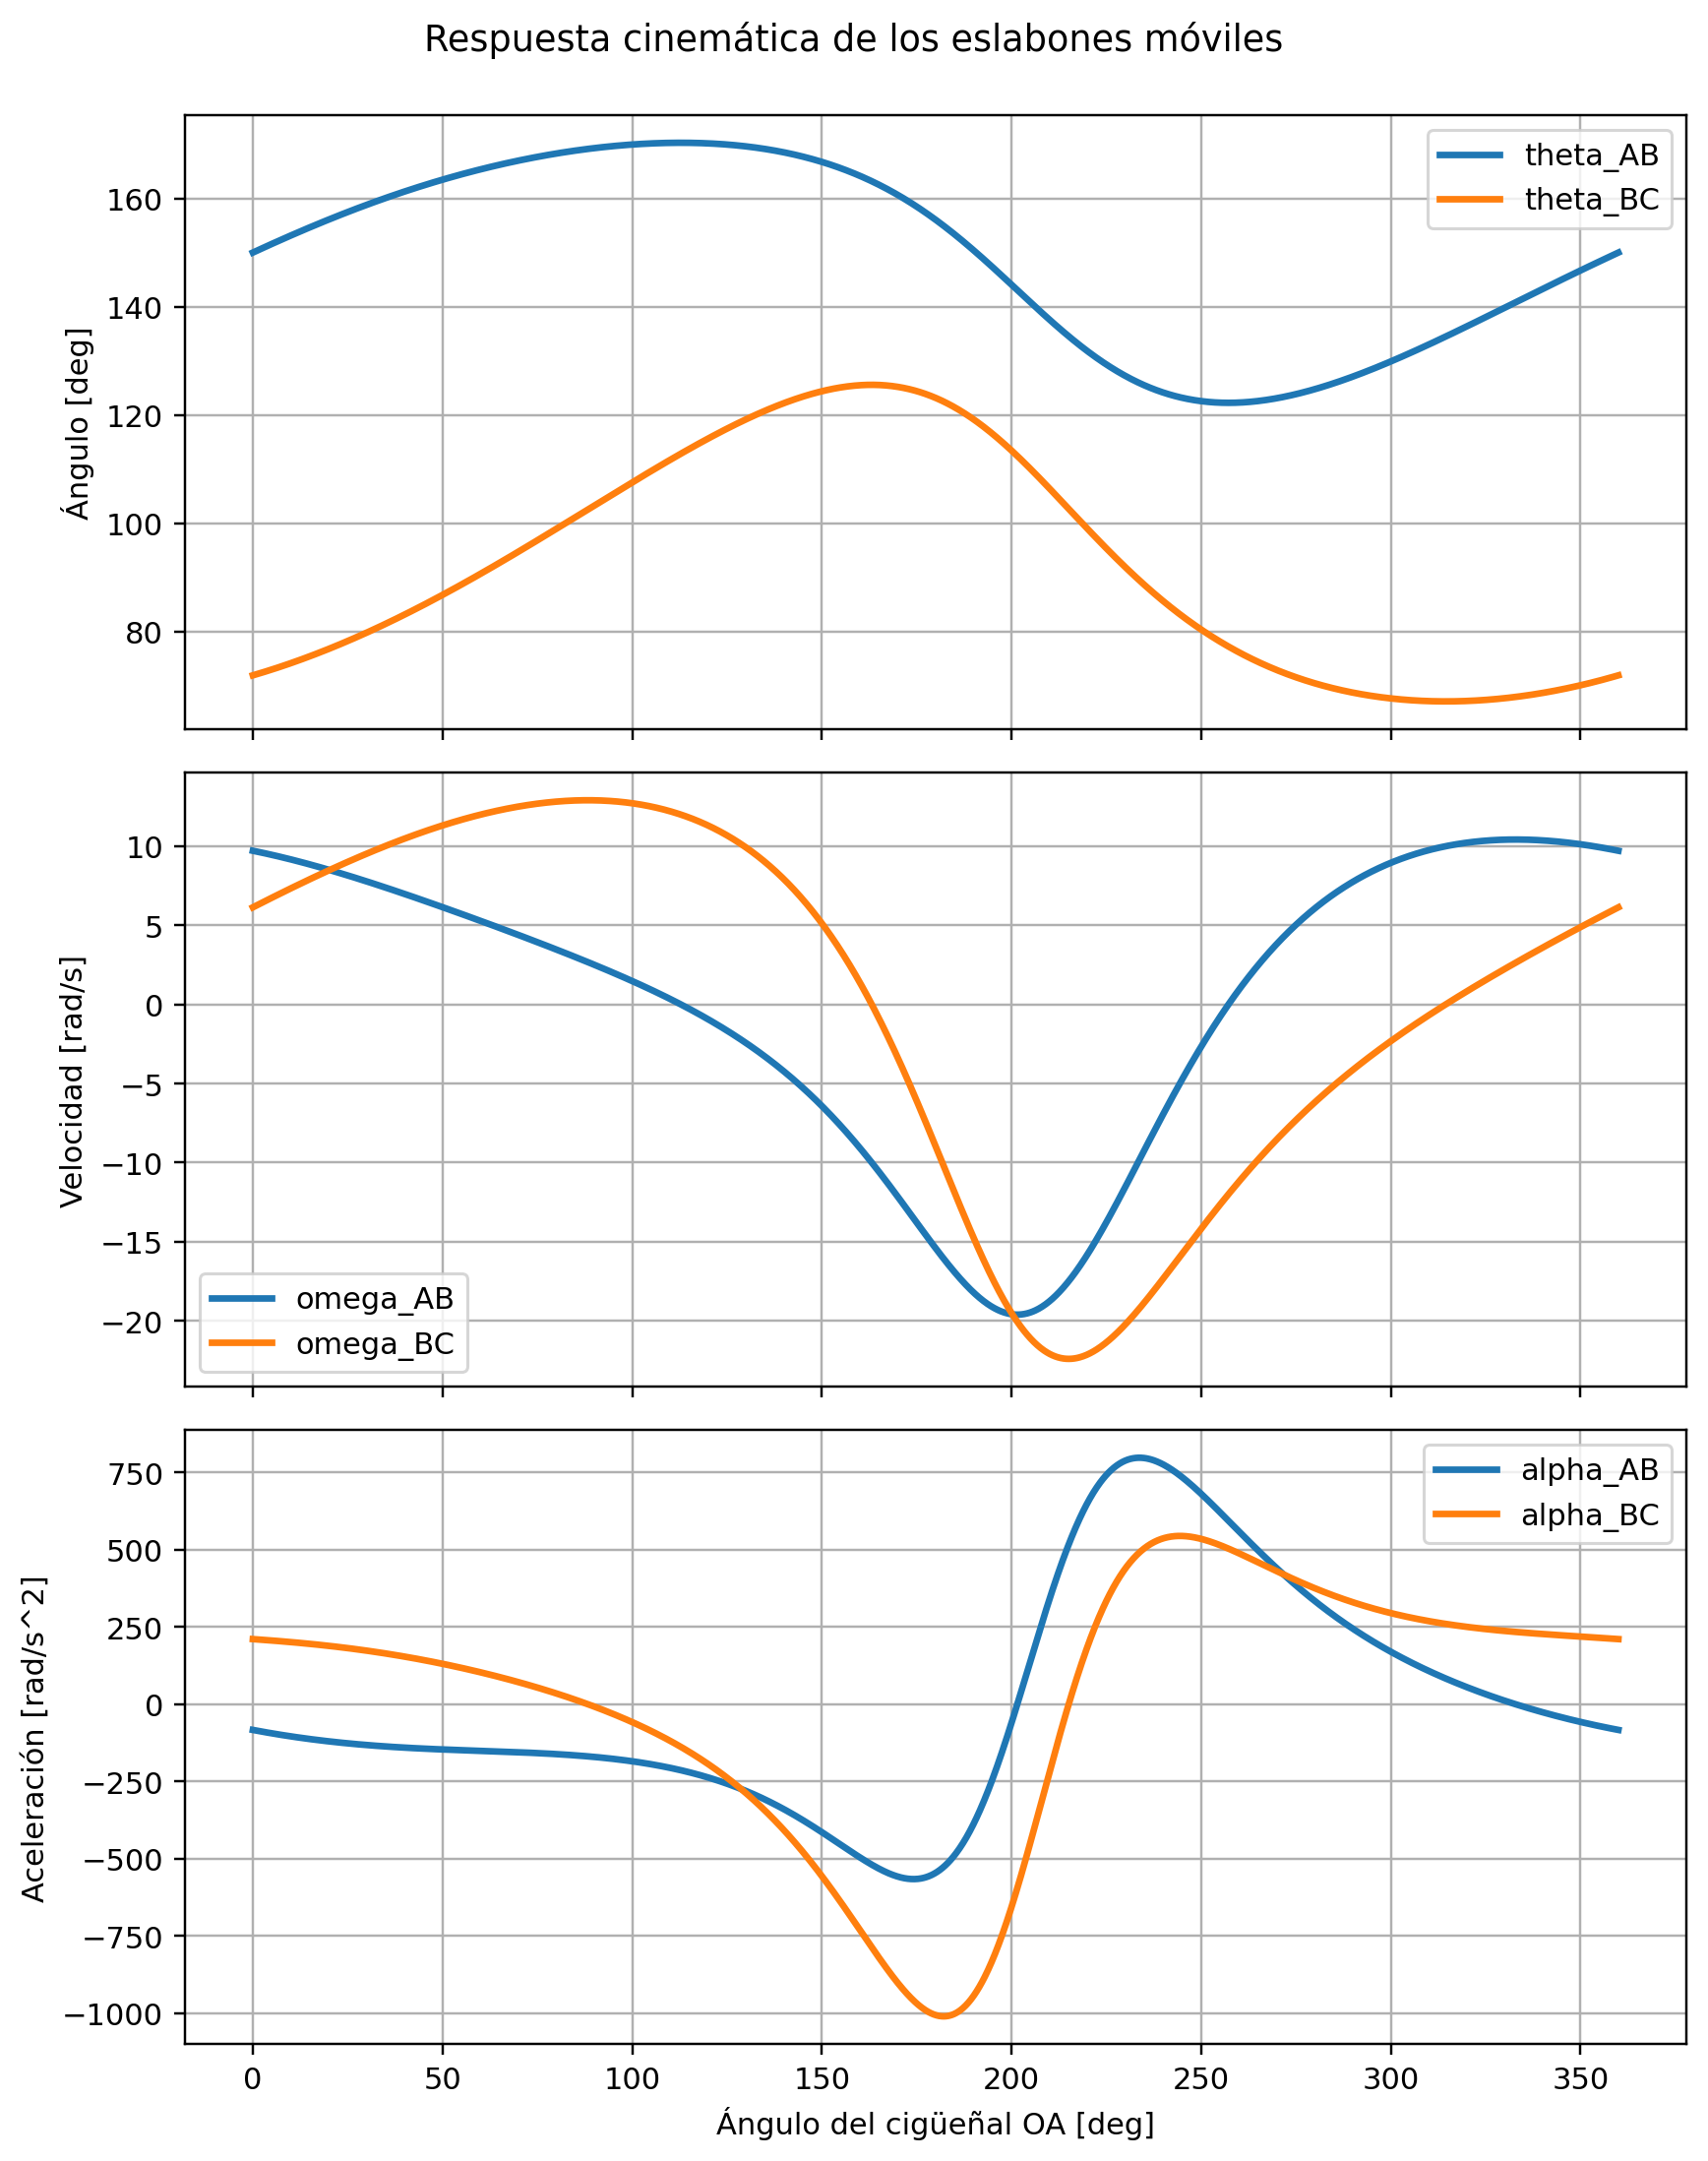

<project-root>/datasets/volante_inercia_6061/03_torque.png


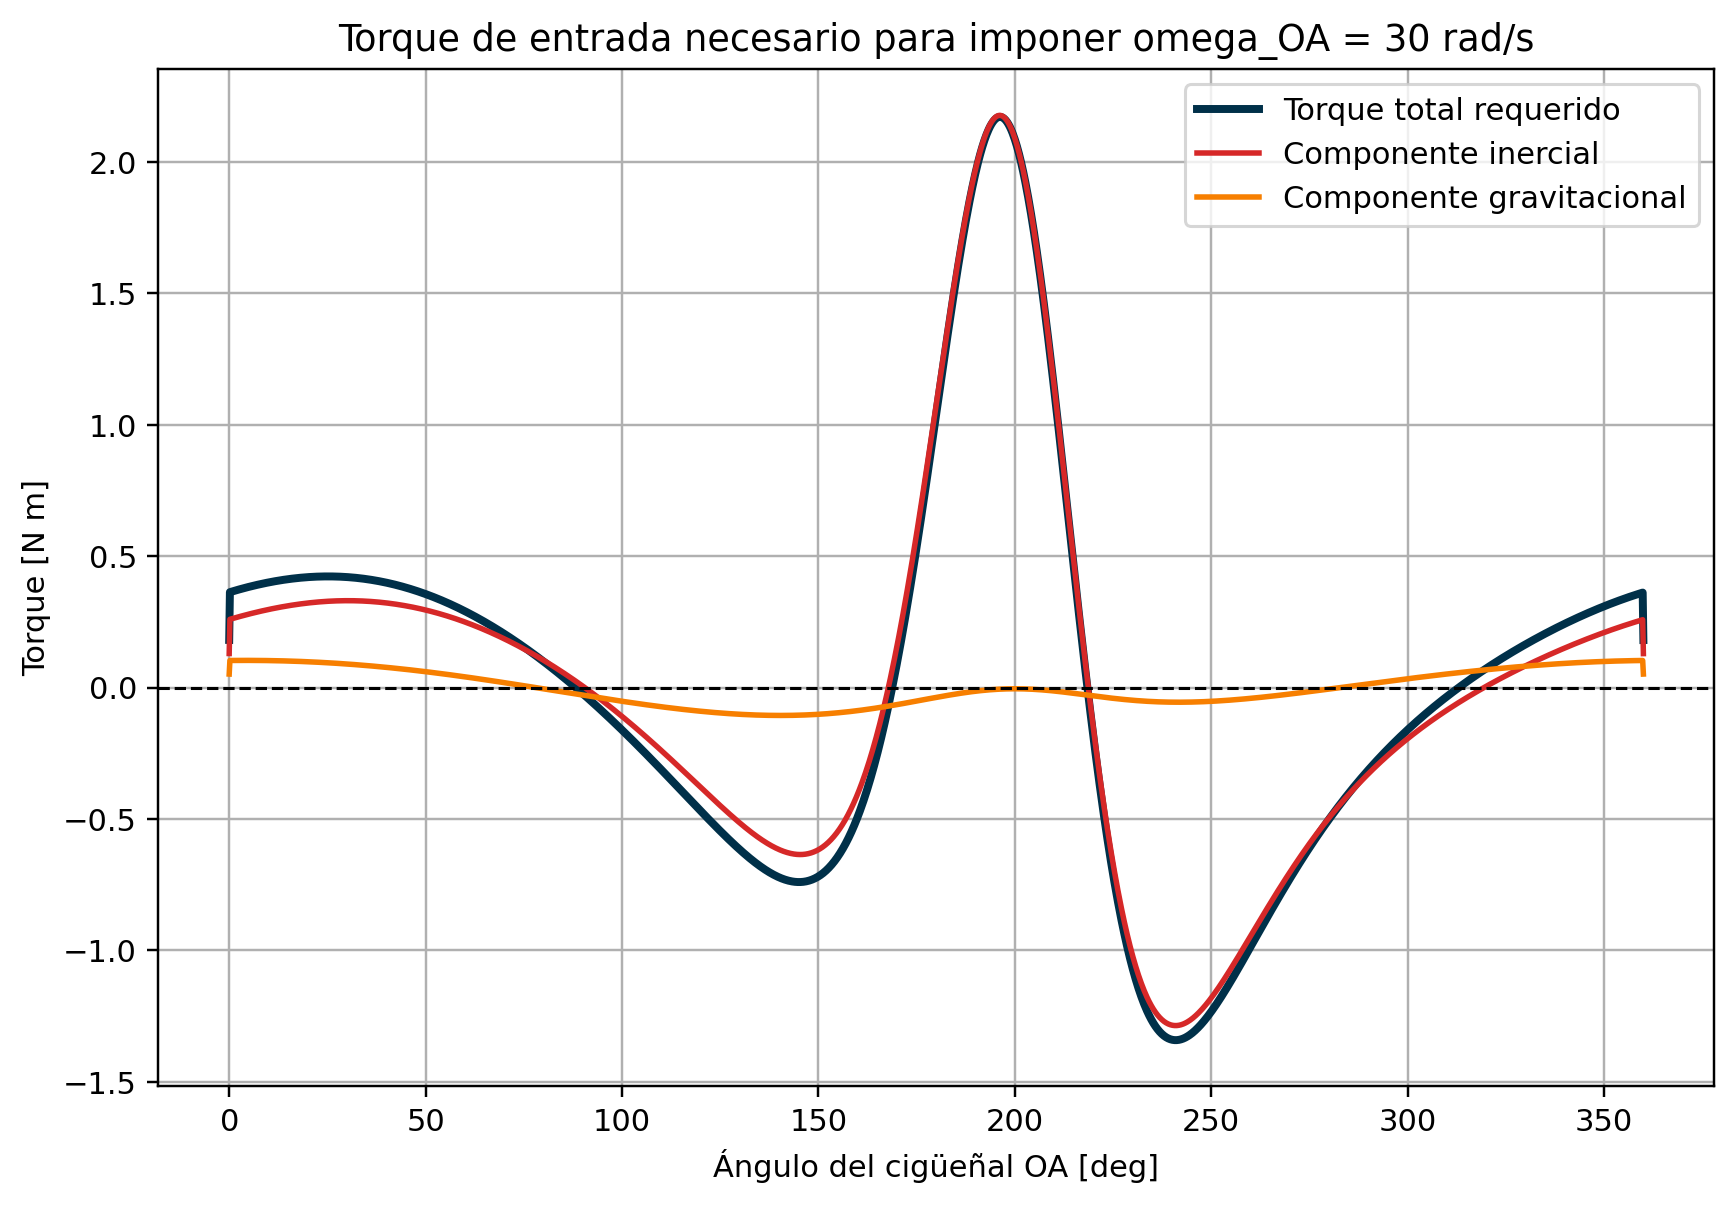

<project-root>/datasets/volante_inercia_6061/04_volante_energia.png


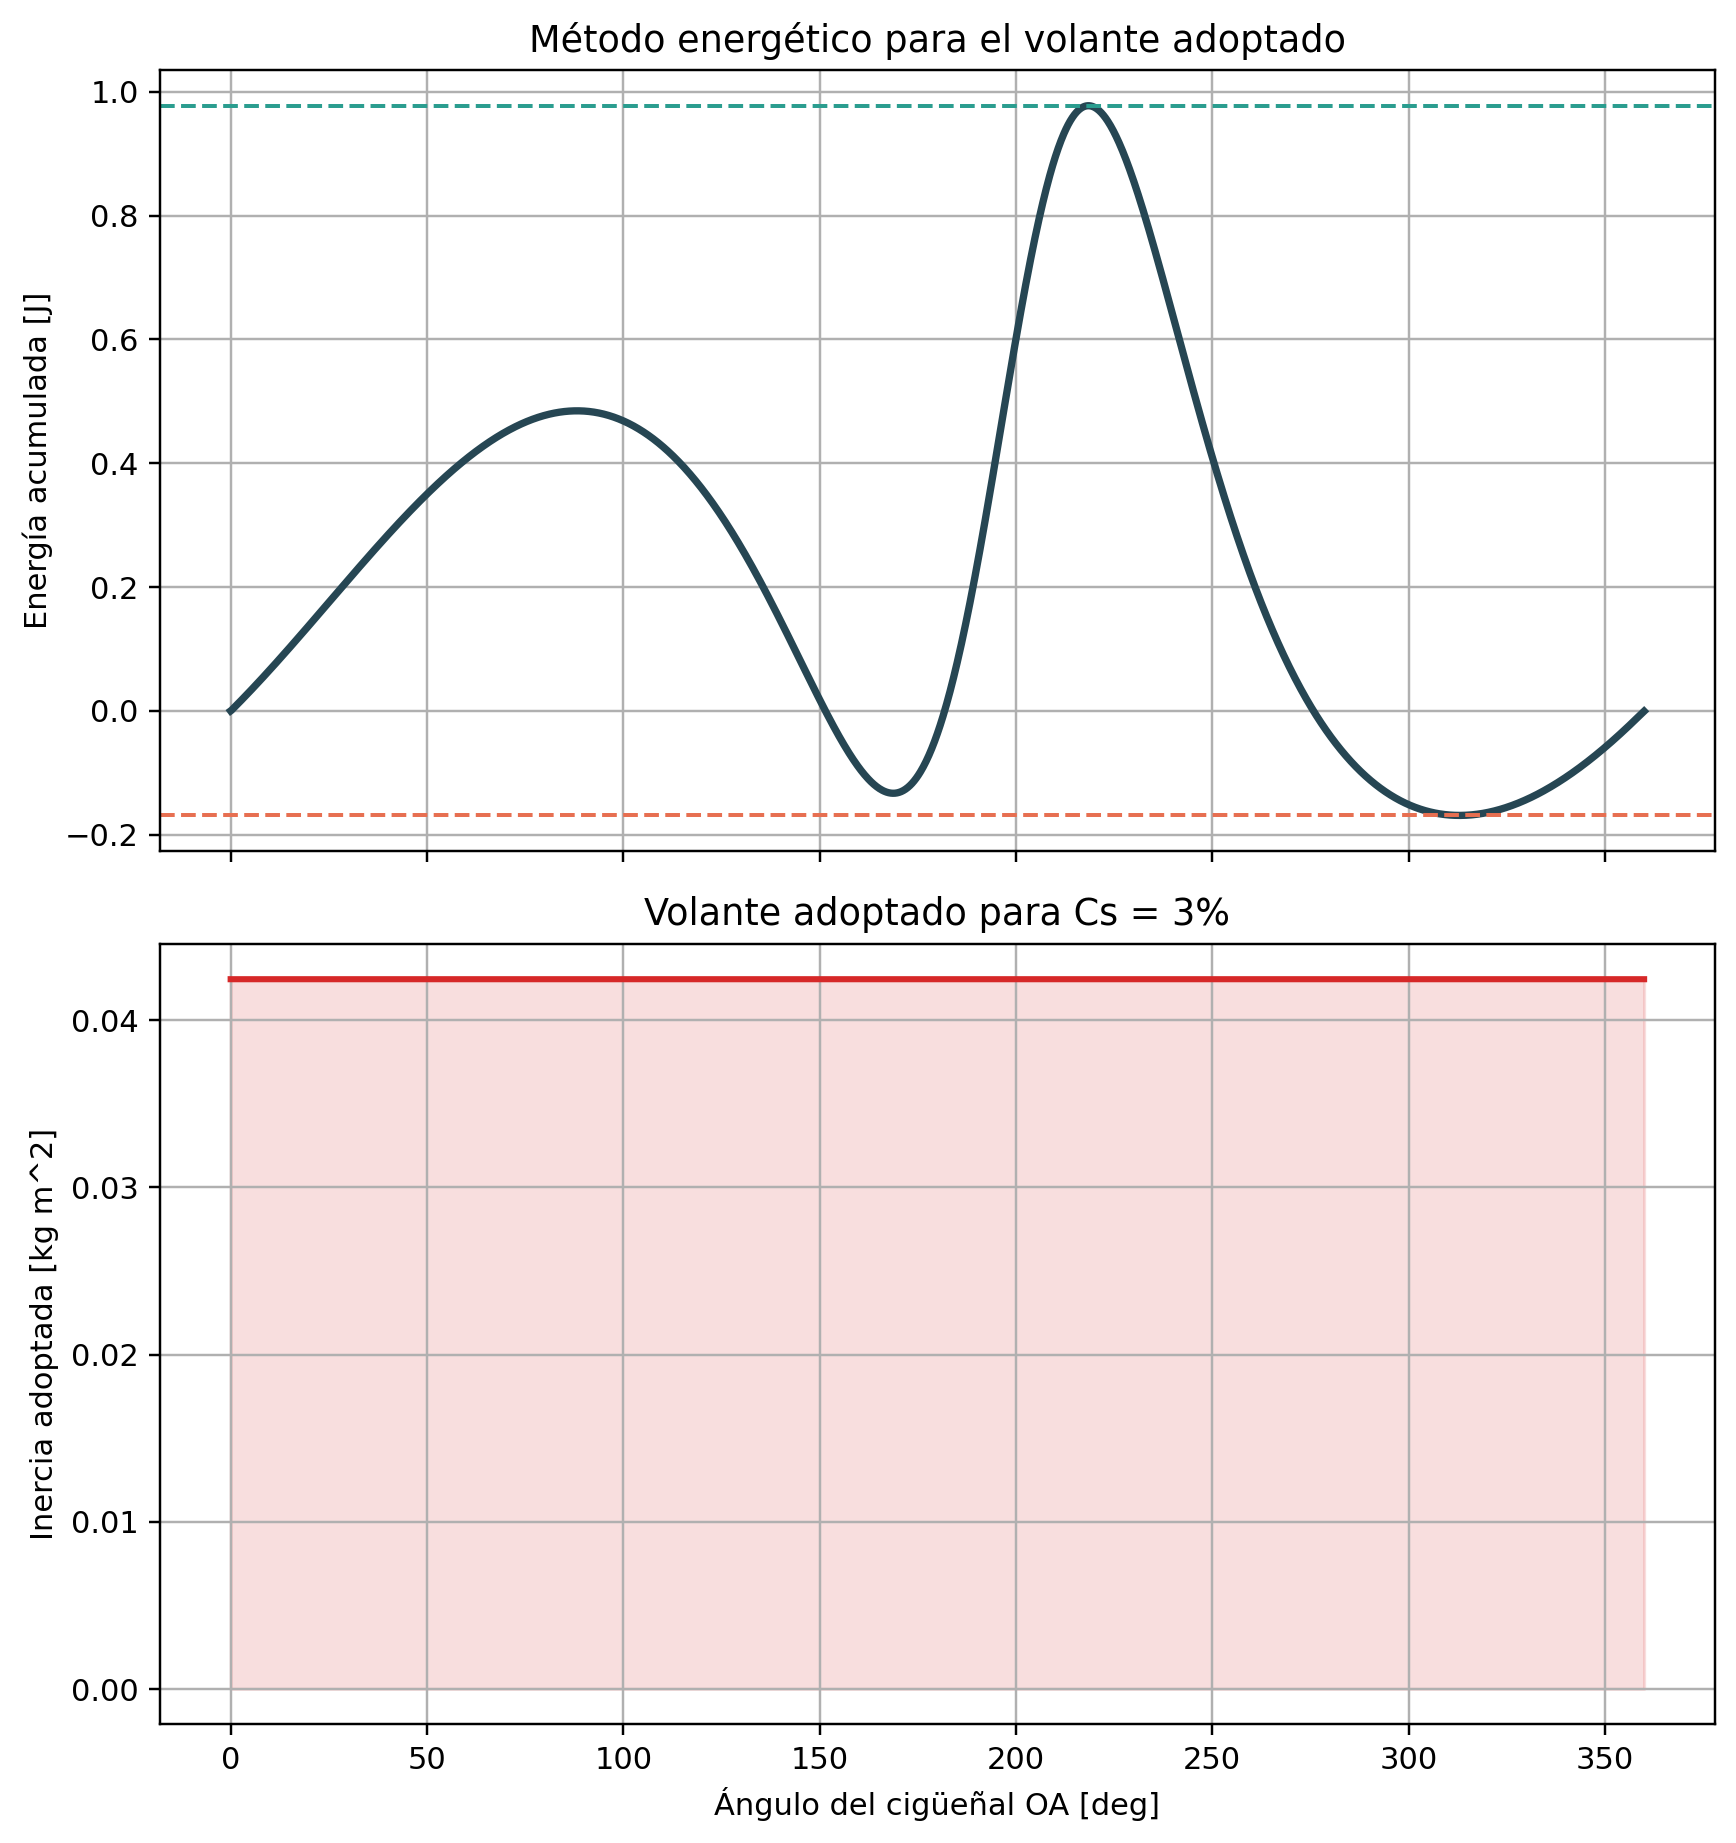

<project-root>/datasets/volante_inercia_6061/05_verificacion_velocidad.png


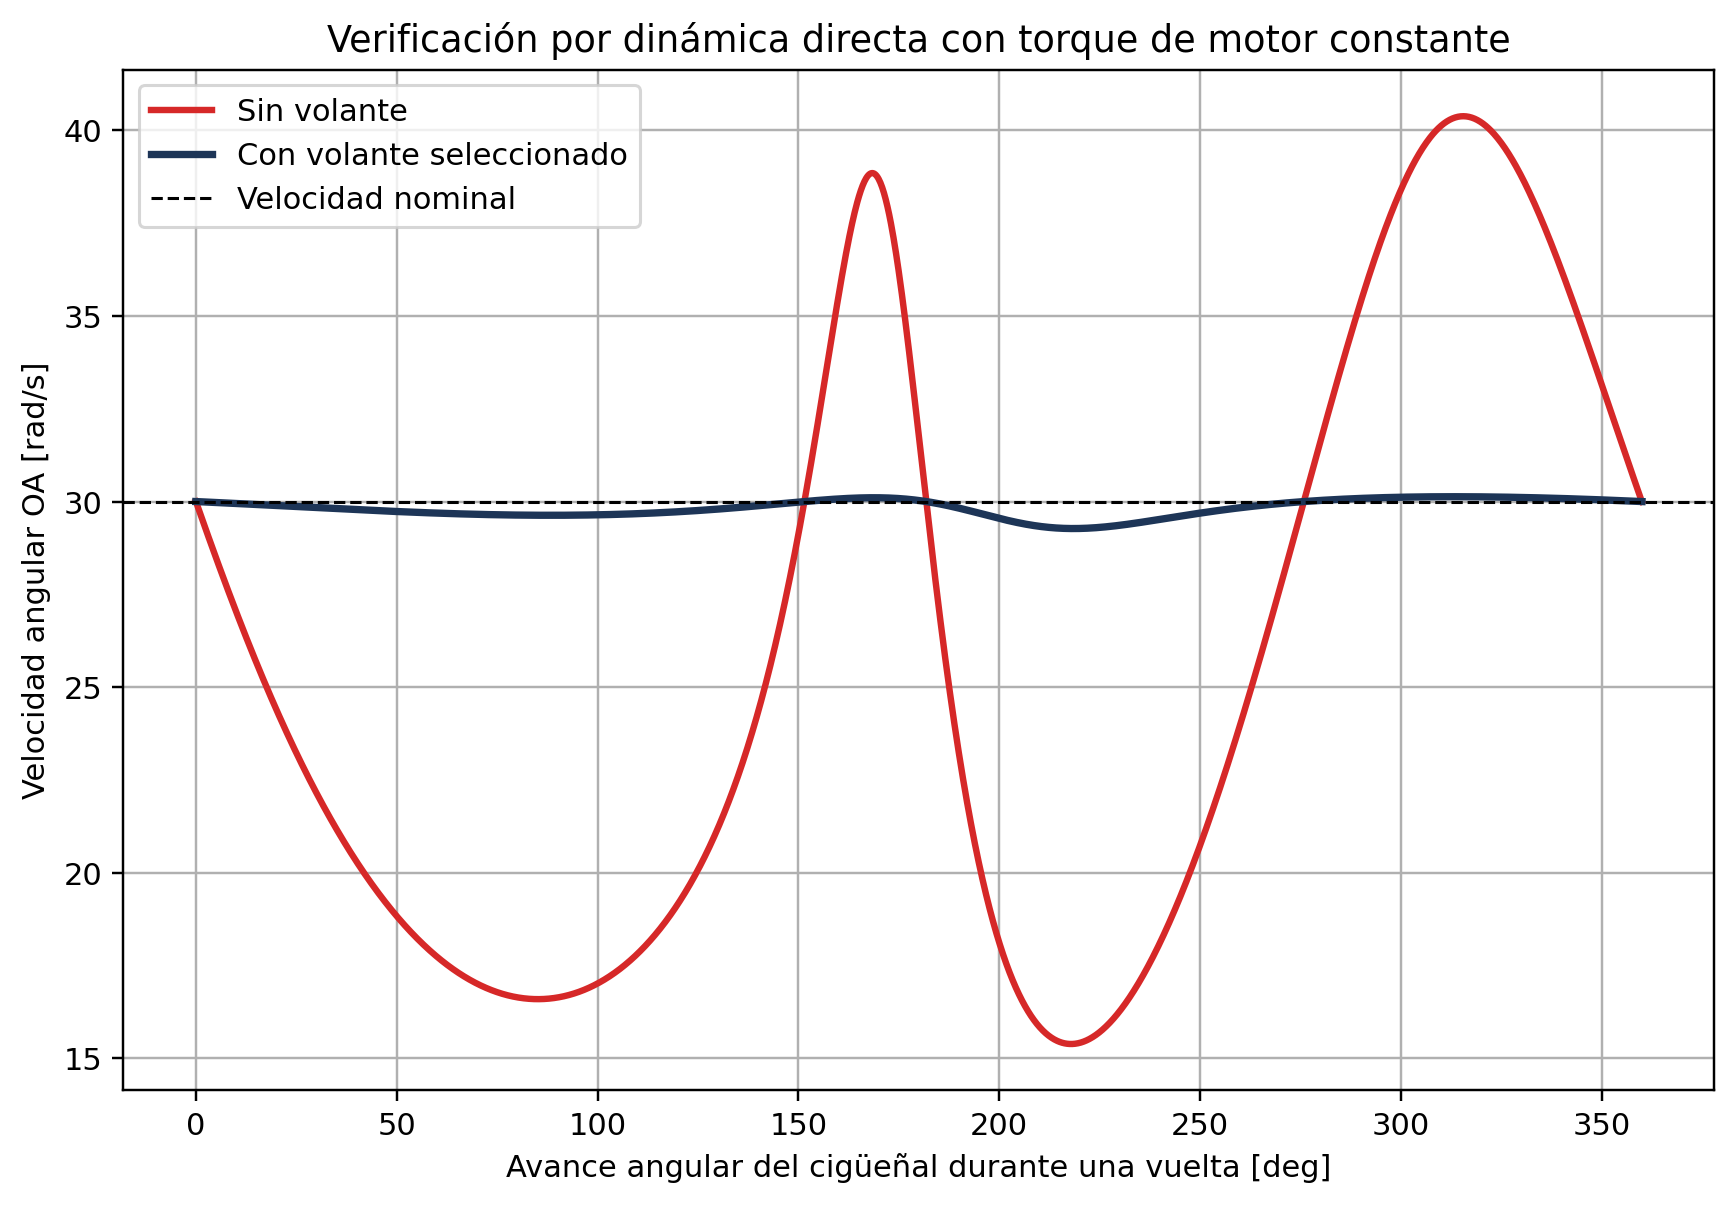

In [8]:
fig1 = plot_mechanism_samples(res)
fig2 = plot_kinematics(res)
fig3 = plot_torque(res)
fig4 = plot_energy(res, I_flywheel, Cs_target)
fig5 = plot_verification(sim_no, sim_yes)

figures = [
    ('01_mecanismo.png', fig1),
    ('02_cinematica.png', fig2),
    ('03_torque.png', fig3),
    ('04_volante_energia.png', fig4),
    ('05_verificacion_velocidad.png', fig5),
]

for name, fig in figures:
    path = OUTPUT_DIR / name
    fig.savefig(path, dpi=220, bbox_inches='tight')
    plt.close(fig)
    print(path)
    display(Image(filename=str(path)))